# Forward and Backward Propagation

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Run a **forward pass** through a small model and compute the loss
- Run **backward pass** (backprop) to compute gradients and perform one weight update
- See how loss changes after one update (optional small plot)

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 2, lesson 04 "Programming Backpropagation in Neural Networks" — forward pass, loss, backward pass: the same three steps, now inside a framework.

---

## 🌍 Real life

**📌 Real case — the paper that explained why deep networks would not train.** Bengio, Simard and Frasconi (*IEEE Transactions on Neural Networks* 5(2), 1994) showed formally what practitioners kept hitting: because backpropagation multiplies a long chain of derivatives together, the gradient reaching the early layers shrinks (or explodes) exponentially with depth. That single result about the **backward** pass is why LSTM gating exists (Unit 3), why ResNet's skip connections exist (`unit2/03`), and why ReLU replaced sigmoid (`unit1/04`). Three of this course's units are answers to a problem in the step you are about to run once, by hand.

**⚡ Why this matters — what goes wrong without it.** The forward pass tells you *how wrong* you are. It says nothing about *which weight to move*. Backpropagation is the only step that assigns blame — and it is the step that fails silently. When a network's loss flattens and you cannot see why, the cause is almost always in the backward pass: a vanished gradient, a NaN, a stray `torch.no_grad()`, a tensor detached from the graph. Below, one forward pass, one backward pass and one update move the loss from **2.3251 to 2.3095**. Watching that single heartbeat is what lets you diagnose it later when it stops.

**Where is this used?** Every neural network training step uses **forward pass** (input → output → loss) and **backward pass** (gradients → weight updates). This is the core of how models learn in production and research.

**In this notebook we use** **forward propagation** to compute predictions and loss, and **backward propagation** to compute gradients and update weights. We use **GradientTape** (instead of writing derivatives by hand) **because** TensorFlow/PyTorch automate backprop so we can focus on architecture and data.

**📌 Covers slide(s):** Part of Unit 1 sequence (forward/backprop). *Do with or after 05_backpropagation_detailed; then 06_optimization_techniques.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Forward pass:** Input → layer 1 → activation → … → output → loss. We compute the loss given current weights.
- **Backward pass (backprop):** We compute gradients of the loss w.r.t. each weight using the chain rule; the framework (e.g. TensorFlow) does this automatically with GradientTape.
- **Update:** Optimizer uses gradients to update weights (e.g. w -= lr * gradient).
- **We use GradientTape** instead of manual derivatives because it scales to large models and is less error-prone.

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, TensorFlow. We use a tiny batch of MNIST (e.g. 32 samples) so one forward + backward step is fast.

**Dataset:** Real — MNIST (tiny batch for forward/backward demo).

**Outputs:** Printed loss before and after one update, and one figure with two panels: the two values drawn on the true scale of the loss (0 = perfect, ln 10 = guessing), and the same update repeated 20 times so the direction becomes visible.

## Step 1: Imports and load a tiny batch

In [1]:
# WHAT: import libraries and prepare a tiny fixed batch of 32 MNIST images.
# WHY: forward/backward propagation is easiest to watch on one small, unchanging batch.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if not HAS_TF:
    print("Install TensorFlow: pip install tensorflow")
else:
    # Scale pixels to 0-1, flatten each image to a 784-long vector, and keep just 32 examples.
    (x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
    x_train = tf.constant(x_train.astype(np.float32) / 255.0)
    x_train = tf.reshape(x_train, (-1, 784))[:32]
    y_train = tf.constant(y_train[:32])
    print("Batch shape:", x_train.shape)

Batch shape: (32, 784)


## Step 2: Build a small model and compute loss (forward pass)

In [2]:
# WHAT: run one forward pass, compute gradients with GradientTape, and apply a single SGD update.
# WHY: this is one heartbeat of training - forward, loss, backward, update - made fully explicit.
if HAS_TF:
    # Fix the seed so the two loss numbers below are the same every run - the text quotes them.
    tf.keras.utils.set_random_seed(1)
    # A small two-layer classifier; plain SGD with a fixed learning rate keeps the update easy to reason about.
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(784,)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    # GradientTape records the forward pass so it can replay it backwards for gradients (backpropagation).
    with tf.GradientTape() as tape:
        logits = model(x_train, training=True)
        loss_before = loss_fn(y_train, logits)
    # tape.gradient computes dLoss/dWeight for every parameter; apply_gradients takes one downhill step.
    grads = tape.gradient(loss_before, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    # Forward pass again after the update - the loss should already be slightly lower.
    logits_after = model(x_train, training=False)
    loss_after = loss_fn(y_train, logits_after)

    loss_before_val = float(loss_before.numpy())
    loss_after_val = float(loss_after.numpy())
    print("Loss before one update: %.4f" % loss_before_val)
    print("Loss after one update:  %.4f" % loss_after_val)

Loss before one update: 2.3251
Loss after one update:  2.3095


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 3: Visualize loss before vs after one update

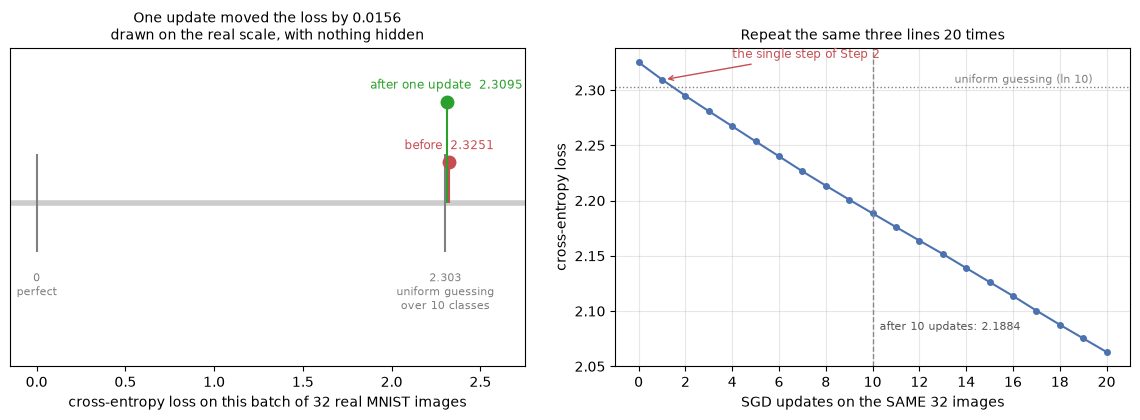

update  0: 2.3251   (before any update; ln 10 = 2.3026)
update  1: 2.3095   (the step taken in Step 2, a fall of 0.0156)
update 10: 2.1884
update 20: 2.0630   (total fall over 20 updates: 0.2622)
Backprop computed the gradients; the optimizer applied the steps.
Careful: these 32 images are the ONLY images the model has seen. A falling loss here
means the update rule works, not that the model can read a digit it has never seen.


In [3]:
# WHAT: two honest views of that single update.
#   (left)  where the loss sits on the scale of the problem, before and after the one step;
#   (right) the same update repeated 20 times, which is the only way to see a direction.
# WHY: a "before vs after" bar chart of one step is the classic dishonest plot - the two bars look
#      identical because the change IS tiny, and the reader is left to take the caption on trust.
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

    # ---------- Left: the true scale ----------------------------------------------------
    ln10 = float(np.log(10))
    ax1.axhline(0, color="#cccccc", lw=4)
    for v, lab in [(0.0, "0\nperfect"), (ln10, f"{ln10:.3f}\nuniform guessing\nover 10 classes")]:
        ax1.vlines(v, -0.3, 0.3, color="grey", lw=1.5)
        ax1.text(v, -0.42, lab, ha="center", va="top", fontsize=8, color="grey")
    # Each value gets a stem standing on the loss axis, so its position is unambiguous.
    ax1.vlines(loss_before_val, 0, 0.25, color="#c44e52", lw=1.5)
    ax1.plot(loss_before_val, 0.25, "o", color="#c44e52", ms=9)
    ax1.text(loss_before_val, 0.33, f"before  {loss_before_val:.4f}", ha="center", fontsize=8.5, color="#c44e52")
    ax1.vlines(loss_after_val, 0, 0.62, color="#2ca02c", lw=1.5)
    ax1.plot(loss_after_val, 0.62, "o", color="#2ca02c", ms=9)
    ax1.text(loss_after_val, 0.70, f"after one update  {loss_after_val:.4f}", ha="center",
             fontsize=8.5, color="#2ca02c")
    ax1.set_xlim(-0.15, 2.75); ax1.set_ylim(-1.0, 0.95)
    ax1.set_yticks([]); ax1.set_xlabel("cross-entropy loss on this batch of 32 real MNIST images")
    ax1.set_title(f"One update moved the loss by {loss_before_val - loss_after_val:.4f}\n"
                  f"drawn on the real scale, with nothing hidden", fontsize=10)

    # ---------- Right: 20 more heartbeats -----------------------------------------------
    track = [loss_before_val, loss_after_val]          # update 0 (none yet) and update 1
    for _ in range(19):
        with tf.GradientTape() as tape:
            l = loss_fn(y_train, model(x_train, training=True))
        g = tape.gradient(l, model.trainable_variables)
        optimizer.apply_gradients(zip(g, model.trainable_variables))
        track.append(float(loss_fn(y_train, model(x_train, training=False)).numpy()))

    ax2.plot(range(len(track)), track, "o-", ms=4, color="#4c72b0")
    ax2.axhline(ln10, color="grey", ls=":", lw=1)
    ax2.text(13.5, ln10 + 0.004, "uniform guessing (ln 10)", fontsize=8, color="grey")
    ax2.annotate("the single step of Step 2", xy=(1.1, track[1]), xytext=(4.0, track[0] + 0.004),
                 fontsize=8.5, color="#c44e52", arrowprops=dict(arrowstyle="->", color="#c44e52"))
    ax2.axvline(10, color="#888888", ls="--", lw=1)
    ax2.text(10.3, track[-1] + 0.02, f"after 10 updates: {track[10]:.4f}", fontsize=8, color="#555555")
    ax2.set_xlabel("SGD updates on the SAME 32 images")
    ax2.set_ylabel("cross-entropy loss")
    ax2.set_xticks(range(0, 21, 2))
    ax2.set_title("Repeat the same three lines 20 times", fontsize=10)
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"update  0: {track[0]:.4f}   (before any update; ln 10 = {ln10:.4f})")
    print(f"update  1: {track[1]:.4f}   (the step taken in Step 2, a fall of {track[0]-track[1]:.4f})")
    print(f"update 10: {track[10]:.4f}")
    print(f"update 20: {track[20]:.4f}   (total fall over 20 updates: {track[0]-track[20]:.4f})")
    print("Backprop computed the gradients; the optimizer applied the steps.")
    print("Careful: these 32 images are the ONLY images the model has seen. A falling loss here")
    print("means the update rule works, not that the model can read a digit it has never seen.")


**Read the figure.**

- **Left — the update on the scale it really lives on.** 0 is a perfect classifier; 2.303 (= ln 10) is a model that answers "all ten digits are equally likely". Before the update we sit at **2.3251**, after it at **2.3095**. The two stems almost touch, and that *is* the finding: one SGD step at lr = 0.01 moved the loss by **0.0156**. An earlier version of this notebook drew exactly this as two bars of visibly equal height with a caption announcing progress — nothing was hidden then either, the change is simply that small, and a student is right to be unconvinced by a picture that shows nothing. Notice too that both stems stand to the *right* of the guessing line: after one update the model is still very slightly worse than answering at random. That is Discuss question 1.
- **Right — the same three lines, twenty times.** Forward pass, backward pass, update, repeated on the same 32 images. Now the direction is unmistakable: 2.3251 → **2.1884** after 10 updates → **2.0630** after 20, in an almost straight line, crossing the guessing line between update 1 and update 2. The red arrow marks the single step the left panel is about.

**What it proves:** the gradient really does point downhill, and following it repeatedly moves the loss. **What it does not prove:** anything at all about reading digits. These 32 images are the only images this model has ever seen — driving the loss to 0.001 here would mean it had memorised 32 pictures, not learned to read. That is Discuss question 2, and the answer is a test set.

## 💬 Discuss

1. Random guessing over 10 classes gives a cross-entropy loss of ln(10) ≈ **2.303**. Our loss *before* any update was **2.3251** — slightly worse than random. Is that a bug or is it expected? Justify your answer from how the weights were initialised.
2. Suppose you ran ten more steps on this same fixed batch of 32 images and the loss reached 0.001. Has the model learned to read digits? State precisely what it has learned, and what you would have to run to tell the difference.
3. `GradientTape` hides the chain rule from you. Name one thing you can no longer diagnose because you did not write the derivatives yourself — and describe how you would recover that visibility without abandoning the framework.


## ⚠️ Where this breaks

- **One step on one fixed batch measures nothing about generalisation.** The 0.0229 drop we printed shows the mechanism works, not that the model learns. Do not quote a single-step loss as a result.
- **The loss is not guaranteed to fall.** With a learning rate that is too large, a single update overshoots the minimum and the loss goes *up*. Ours fell; that is one draw from a distribution, not a law. If you re-run with `lr=10` you will see the other outcome.
- **This is exactly where depth fails.** Multiply enough derivatives smaller than 1 and the gradient arriving at layer 1 is numerically zero. The network then trains its last layers while the first ones sit at their random initial values — and the loss curve looks perfectly normal while it happens. The only way to see it is to print gradient norms per layer, which no automatic tool does for you.
- **The assumption that must hold:** the graph is connected and everything in it is differentiable. A `.detach()`, an in-place operation, a `requires_grad=False` left over from a frozen-backbone experiment (`unit2/05`), or a `no_grad()` block in the wrong place all produce zero gradients — and a model that appears to train while changing nothing.
- **Cheaper alternative for understanding:** for a two-parameter model you can differentiate the loss by hand on paper in five minutes and check `GradientTape` against it. Do this once. It is the only way to ever fully trust autodiff again.


## 🧩 Mini-exercise

**Try it:** Run the training step (optimizer step) two more times in a new cell (same batch). Print the loss after each step. Does it keep decreasing?

---

## ✅ Summary

**What you did:**
- Ran a forward pass (input → model → loss) and backward pass (GradientTape → gradients → optimizer step).
- Compared loss before and after one update and plotted it.

**In real life you'd also:** Run many epochs, use validation loss, and save checkpoints.

**The main idea:** Training = repeat (forward → loss → backprop → update). Frameworks automate backprop so we don't write derivatives by hand.

**Next:** `05_backpropagation_detailed` goes deeper into how gradients flow; `06_optimization_techniques` compares optimizers.

## 📚 References

1. Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature 323, 533-536. https://doi.org/10.1038/323533a0
2. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning* (ch. 6). MIT Press. https://www.deeplearningbook.org/
3. Baydin, A. G., Pearlmutter, B. A., Radul, A. A. & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: a Survey*. JMLR 18(153). https://arxiv.org/abs/1502.05767

**Recent work (2024–2026)**

4. Zhao, J. et al. (2024). *GaLore: Memory-Efficient LLM Training by Gradient Low-Rank Projection*. ICML 2024. https://arxiv.org/abs/2403.03507 — the forward/backward pass you traced by hand, at scale, is bounded by what the optimizer state costs to store.
5. Ansel, J. et al. (2024). *PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation*. ASPLOS '24. https://doi.org/10.1145/3620665.3640366 — how the framework fuses that same forward and backward graph into compiled kernels instead of executing it op by op.
